# Phase 2 — Synthetic Data + Pretraining (Colab)
**DocLayout-YOLO-Indic**

Runs the Phase 2 data engine and pretraining on Colab. Key design choices for Colab:
- **Code** lives in Drive (`MyDrive/doclayout-yolo-indic`), same as Phase 1.
- **Generation writes to LOCAL `/content`** (fast), then we tar the ~7 GB corpus and copy *one* file to Drive. (Never write 150K small files straight to Drive — it is slow and hits file-count limits.)
- **Data generation** = T4 or any runtime (CPU-bound, parallelised). **Pretraining** = A100.

Runtime: `Runtime → Change runtime type` → **T4** for Cells 0–5, switch to **A100** for Cell 6.

## Cell 0 — Bootstrap (mount Drive, install data-engine deps)

In [1]:
import os, sys, subprocess, json
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
PROJECT_ROOT = Path('/content/drive/MyDrive/doclayout-yolo-indic')
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))

# Data-engine deps only (CPU). Training deps installed later in Cell 6.
subprocess.run(['pip','install','-q','uharfbuzz','fonttools','pillow','numpy','tqdm'], check=True)

import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
print('vCPUs   :', os.cpu_count())
print('PROJECT_ROOT:', PROJECT_ROOT)

Mounted at /content/drive
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
vCPUs   : 2
PROJECT_ROOT: /content/drive/MyDrive/doclayout-yolo-indic


## Cell 1 — Get the Phase 2 code from GitHub
Clones your repo, unzips the code bundle, and syncs it into `PROJECT_ROOT` so the rest of the notebook works unchanged. Re-run anytime to pull the latest.

In [2]:
import subprocess, shutil, zipfile
from pathlib import Path

FORCE_REFRESH = True   # True = re-pull latest code from GitHub

if (PROJECT_ROOT / 'src' / 'synthetic_data' / 'resumable.py').exists() and not FORCE_REFRESH:
    print('Code already in Drive — skipping clone. Set FORCE_REFRESH=True to update.')
else:
    GITHUB_URL    = 'https://github.com/vigneshpalanivelr/mtech-project-aiml.git'  # set this
    GITHUB_BRANCH = 'main'
    REPO_LOCAL    = Path('/content/_repo')
    if (REPO_LOCAL / '.git').exists():
        subprocess.run(['git','-C',str(REPO_LOCAL),'pull','--ff-only'], check=True)
    else:
        shutil.rmtree(REPO_LOCAL, ignore_errors=True)
        subprocess.run(['git','clone','--depth','1','-b',GITHUB_BRANCH,
                        GITHUB_URL, str(REPO_LOCAL)], check=True)
    zip_path = REPO_LOCAL / 'files' / 'doclayout-yolo-indic.zip'
    assert zip_path.exists(), f'Zip not found at {zip_path}'
    unzip_dir = Path('/content/_unzipped'); shutil.rmtree(unzip_dir, ignore_errors=True)
    with zipfile.ZipFile(zip_path) as z: z.extractall(unzip_dir)
    src_root = next(p.parent.parent for p in unzip_dir.rglob('src/config.py'))
    for item in ['src','tests','requirements.txt','README.md']:
        s = src_root / item; d = PROJECT_ROOT / item
        if s.is_dir(): shutil.rmtree(d, ignore_errors=True); shutil.copytree(s, d)
        elif s.exists(): shutil.copy(s, d)
    print('Code synced to', PROJECT_ROOT, 'OK')

assert (PROJECT_ROOT / 'src' / 'synthetic_data' / 'generator.py').exists()

Code synced to /content/drive/MyDrive/doclayout-yolo-indic OK


## Cell 2 — Fonts (downloads ~5 MB of Noto fonts into Drive, cached)

In [3]:
%cd {PROJECT_ROOT}
!python -m src.synthetic_data.font_setup

/content/drive/MyDrive/doclayout-yolo-indic
14:19:08 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoNaskhArabic.ttf
14:19:09 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSans.ttf
14:19:09 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansBengali.ttf
14:19:10 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansDevanagari.ttf
14:19:10 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansGujarati.ttf
14:19:11 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansGurmukhi.ttf
14:19:11 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansKannada.ttf
14:19:12 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansMalayalam.ttf
14:19:13 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansOriya.ttf
14:19:14 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansTamil.ttf
14:19:15 | INFO    | doclayout_indic.__main__ | OK (cached)  NotoSansTelugu.ttf
14:19:16 | INFO    | doclayout_indic.__main__ | Fonts ready for 11/11 

## Cell 3 — Pilot: 200 pages + visual QC (the Week-3 quality gate)
Generates a small batch to **local disk** and shows a contact sheet inline. Eyeball it (ideally with a native reader): shirorekha present, conjuncts/matras correct, Urdu reads right-to-left, boxes tight. Do not proceed to full generation until this looks right.

/content/drive/MyDrive/doclayout-yolo-indic
14:19:16 | INFO    | doclayout_indic.__main__ | Generating 200 docs with 2 workers in 1 chunks -> /content/pilot
14:19:16 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoNaskhArabic.ttf
14:19:16 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSans.ttf
14:19:16 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansBengali.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansDevanagari.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansGujarati.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansGurmukhi.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansKannada.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansMalayalam.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansOriya.ttf
14:19:17 | INFO    | doclayout_indic.font_setup | OK (cached)  NotoSansTamil.ttf
14:19:18 | INFO  

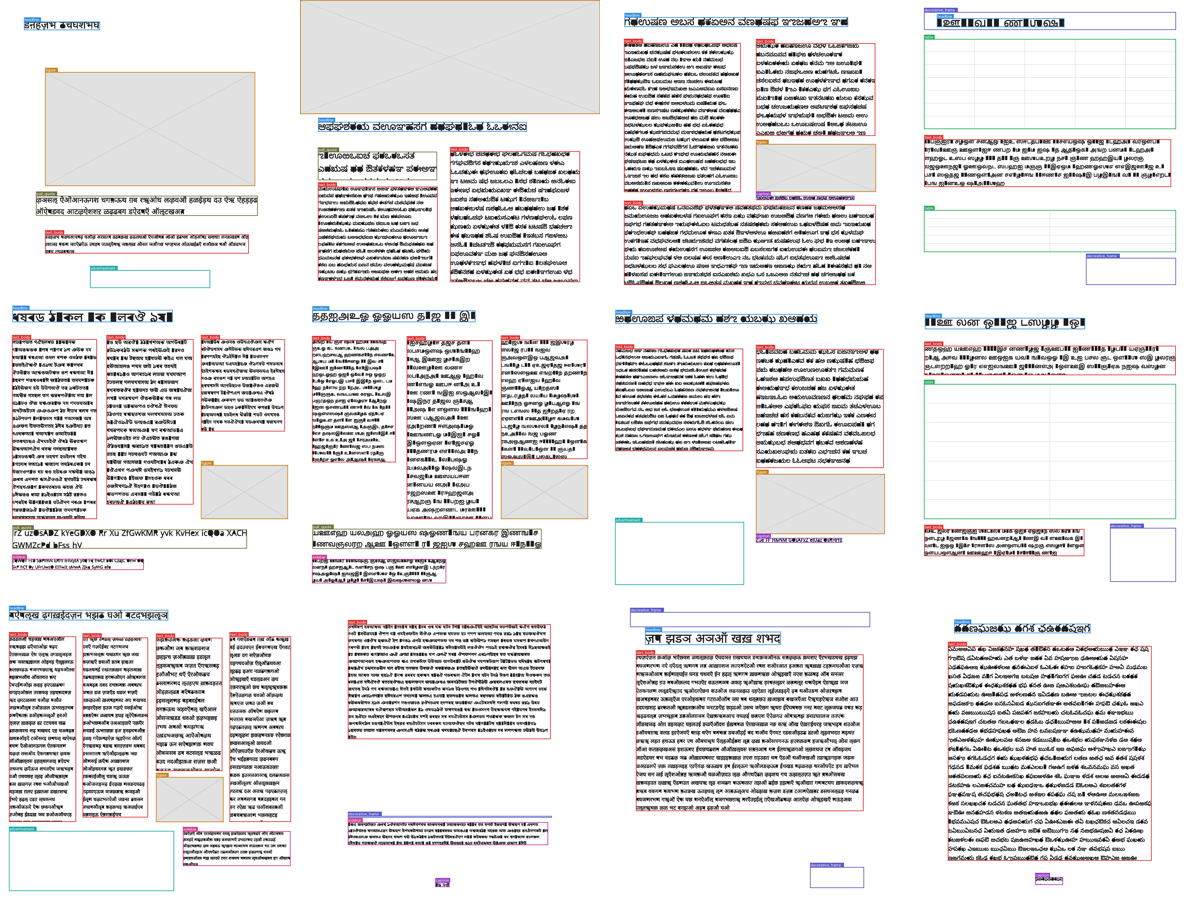

In [4]:
%cd {PROJECT_ROOT}
!python -m src.synthetic_data.parallel --num 200 --tag pilot --out /content/pilot --workers $(nproc)

# inline contact sheet from the LOCAL pilot dir
import json
from pathlib import Path
from PIL import Image
from src.synthetic_data.quality_inspector import overlay
root = Path('/content/pilot')
thumbs=[]
for i in range(1, 13):
    rec = json.loads((root/'annotations'/f'pilot_{i:06d}.json').read_text())
    img = overlay(root/'images'/rec['image_file'], rec['annotations'])
    thumbs.append(img.resize((300,300)))
sheet = Image.new('RGB',(4*300,3*300),'white')
for k,t in enumerate(thumbs):
    r,c=divmod(k,4); sheet.paste(t,(c*300,r*300))
sheet.save('/content/pilot_contact_sheet.png')
from IPython.display import Image as IPImage, display
display(IPImage('/content/pilot_contact_sheet.png'))

## Cell 4 — Generate the corpus (RESUMABLE; shards saved to Drive)
CPU-bound — the **GPU is unused**, so run this on a cheap high-RAM/T4 runtime, not the A100. ~1.1 s/page single-core → roughly **6 h for 150K on 8 vCPUs**.

Generation happens in shards; each finished shard is saved to `shards/` on Drive, so a disconnect never loses completed work. **If it disconnects, just re-run this same cell** — it skips finished shards and continues.

Start with `N = 30000` for the pilot, then set `150000`. Save the A100 for Cell 6.

In [5]:
%cd {PROJECT_ROOT}
from pathlib import Path
import shutil
from src.synthetic_data.resumable import generate_resumable

N = 150000
SHARD_DIR = PROJECT_ROOT / 'shards'
HF_REPO   = 'VigneshPR/indicsynth-150k'
FORCE_REGEN = False

BEST = PROJECT_ROOT/'output'/'logs'/'indicsynth_pretrain'/'weights'/'best.pt'
CKPT = PROJECT_ROOT/'output'/'checkpoints'/'doclayout_yolo_indic_pretrained.pt'
def _have(d): return d.exists() and len(list(d.glob('indicsynth_shard_*.tar'))) > 0

if (BEST.exists() or CKPT.exists()) and not FORCE_REGEN:
    print('Pretraining checkpoint exists -> corpus not needed. Skipping generation.')
elif _have(SHARD_DIR):
    print(f'Corpus already on Drive ({len(list(SHARD_DIR.glob("indicsynth_shard_*.tar")))} shards). Skipping.')
else:
    restored = False
    try:
        from huggingface_hub import snapshot_download
        dl = snapshot_download(repo_id=HF_REPO, repo_type='dataset',
                               allow_patterns='shards/*.tar', local_dir='/content/hf_corpus')
        src = Path(dl)/'shards'
        if _have(src):
            SHARD_DIR.mkdir(parents=True, exist_ok=True)
            for t in src.glob('*.tar'): shutil.copy(t, SHARD_DIR/t.name)
            restored = _have(SHARD_DIR)
    except Exception as e:
        print('HF restore unavailable:', e)
    if restored:
        print('Restored corpus shards from HF.')
    else:
        print('No cached corpus anywhere -> generating (slow path).')
        generate_resumable(num_docs=N, tag='indicsynth', work_dir=Path('/content/work'),
                           drive_dir=SHARD_DIR, shard_size=5000, workers=0)
print('Shards on Drive:', len(list(SHARD_DIR.glob('indicsynth_shard_*.tar'))) if SHARD_DIR.exists() else 0)

/content/drive/MyDrive/doclayout-yolo-indic
Pretraining checkpoint exists -> corpus not needed. Skipping generation.
Shards on Drive: 30


## Cell 4b — Upload corpus to HuggingFace, then free up

*   List item
*   List item

storage
Uploads the `shards/` corpus to a HF dataset (your durable store), **verifies** every shard arrived, then deletes the local scratch and — only after a verified upload — the Drive copy, reclaiming Drive space. Run this *after* Cell 4 has produced all shards. Needs a HF **write** token.

In [7]:
!pip install -q huggingface_hub
import os, shutil
from pathlib import Path
from huggingface_hub import HfApi, login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
HF_REPO  = 'VigneshPR/indicsynth-150k'              # change to your namespace
FORCE_REUPLOAD = False                              # True = upload again even if present
FREE_DRIVE_AFTER_UPLOAD = False                     # delete Drive shards once verified
assert HF_TOKEN, 'Set a HuggingFace write token first'
login(token=HF_TOKEN)
api = HfApi()

# skip if the corpus is already on HF
try:
    remote = [f for f in api.list_repo_files(HF_REPO, repo_type='dataset') if f.endswith('.tar')]
except Exception:
    remote = []
if remote and not FORCE_REUPLOAD:
    print(f'{len(remote)} shards already on HF — skipping upload.')
else:
    SHARD_DIR = PROJECT_ROOT / 'shards'
    local_tars = sorted(SHARD_DIR.glob('indicsynth_shard_*.tar'))
    assert local_tars, f'No shards in {SHARD_DIR} and none on HF — run Cell 4 first'
    api.create_repo(HF_REPO, repo_type='dataset', private=True, exist_ok=True)
    api.upload_folder(folder_path=str(SHARD_DIR), path_in_repo='shards',
                      repo_id=HF_REPO, repo_type='dataset')
    remote = {Path(f).name for f in api.list_repo_files(HF_REPO, repo_type='dataset') if f.endswith('.tar')}
    missing = [t.name for t in local_tars if t.name not in remote]
    assert not missing, f'Upload incomplete, NOT cleaning up. Missing: {missing}'
    print(f'Verified all {len(local_tars)} shards on HF -> https://huggingface.co/datasets/{HF_REPO}')
    shutil.rmtree('/content/work', ignore_errors=True)
    if FREE_DRIVE_AFTER_UPLOAD:
        shutil.rmtree(SHARD_DIR, ignore_errors=True)
        print('Freed Drive shards; Cell 5 will pull from HF.')

30 shards already on HF — skipping upload.


## Cell 5 — Assemble shards + convert to YOLO (CPU)
Uses the Drive `shards/` if present; otherwise downloads them from your HF dataset. Then merges into one COCO and builds YOLO labels + `data.yaml`. Idempotent — safe to re-run.

In [8]:
%cd {PROJECT_ROOT}
from pathlib import Path
from src.synthetic_data.resumable import assemble_from_shards
from src.pretraining.train_synthetic import coco_to_yolo

HF_REPO = 'VigneshPR/indicsynth-150k'
FORCE = False
BEST = PROJECT_ROOT/'output'/'logs'/'indicsynth_pretrain'/'weights'/'best.pt'
CKPT = PROJECT_ROOT/'output'/'checkpoints'/'doclayout_yolo_indic_pretrained.pt'
DATA = Path('/content/yolo_dataset/data.yaml')

if (BEST.exists() or CKPT.exists()) and not FORCE:
    print('Pretraining complete -> YOLO dataset not needed. Skipping. (FORCE=True to rebuild.)')
elif DATA.exists():
    print('YOLO dataset already present at', DATA)
else:
    SHARD_DIR = PROJECT_ROOT / 'shards'
    if SHARD_DIR.exists() and list(SHARD_DIR.glob('indicsynth_shard_*.tar')):
        shards_src = SHARD_DIR
    else:
        from huggingface_hub import snapshot_download
        dl = snapshot_download(repo_id=HF_REPO, repo_type='dataset',
                               allow_patterns='shards/*.tar', local_dir='/content/hf_corpus')
        shards_src = Path(dl) / 'shards'
    print('Using shards from:', shards_src)
    coco, images = assemble_from_shards('indicsynth', shards_src, Path('/content/IndicSynth'))
    yaml_path = coco_to_yolo(coco, images, Path('/content/yolo_dataset'))
    print(yaml_path.read_text())

/content/drive/MyDrive/doclayout-yolo-indic
Pretraining complete -> YOLO dataset not needed. Skipping. (FORCE=True to rebuild.)


## Cell 6 — Pretrain on A100  ⚠️ switch runtime to A100 first
Installs training deps + the DocLayout-YOLO package, downloads the **DocSynth300K-pretrained** checkpoint (the correct initializer — see notes), and trains for 30 epochs.

In [9]:
%cd {PROJECT_ROOT}
from pathlib import Path
import shutil, subprocess, sys
BEST = PROJECT_ROOT/'output'/'logs'/'indicsynth_pretrain'/'weights'/'best.pt'
CKPT = PROJECT_ROOT/'output'/'checkpoints'/'doclayout_yolo_indic_pretrained.pt'
HF_REPO = 'VigneshPR/indicsynth-150k'
FORCE_RETRAIN = False

if (BEST.exists() or CKPT.exists()) and not FORCE_RETRAIN:
    if not CKPT.exists() and BEST.exists():
        CKPT.parent.mkdir(parents=True, exist_ok=True); shutil.copy(BEST, CKPT)
    print('Pretraining already complete -> skipping (no install, no training).')
    print('Checkpoint:', CKPT if CKPT.exists() else BEST)
else:
    subprocess.run([sys.executable,'-m','pip','install','-q','ultralytics','pycocotools'])
    subprocess.run([sys.executable,'-m','pip','install','-q',
                    'git+https://github.com/opendatalab/DocLayout-YOLO.git'])
    from src.pretraining.train_synthetic import download_base_checkpoint, train, coco_to_yolo
    DATA = Path('/content/yolo_dataset/data.yaml')
    if not DATA.exists():
        from src.synthetic_data.resumable import assemble_from_shards
        SHARD_DIR = PROJECT_ROOT / 'shards'
        if SHARD_DIR.exists() and list(SHARD_DIR.glob('indicsynth_shard_*.tar')):
            shards_src = SHARD_DIR
        else:
            from huggingface_hub import snapshot_download
            dl = snapshot_download(repo_id=HF_REPO, repo_type='dataset',
                                   allow_patterns='shards/*.tar', local_dir='/content/hf_corpus')
            shards_src = Path(dl)/'shards'
        coco, images = assemble_from_shards('indicsynth', shards_src, Path('/content/IndicSynth'))
        coco_to_yolo(coco, images, Path('/content/yolo_dataset'))
    ckpt = download_base_checkpoint('/content')
    train(DATA, ckpt)

/content/drive/MyDrive/doclayout-yolo-indic
Pretraining already complete -> skipping (no install, no training).
Checkpoint: /content/drive/MyDrive/doclayout-yolo-indic/output/checkpoints/doclayout_yolo_indic_pretrained.pt


In [10]:
from pathlib import Path
w = Path('/content/drive/MyDrive/doclayout-yolo-indic/output/logs/indicsynth_pretrain/weights')
print([p.name for p in w.glob('*.pt')])   # expect best.pt, last.pt, epoch5/10/15.pt

['epoch5.pt', 'epoch10.pt', 'last.pt', 'best.pt']


In [11]:
from pathlib import Path
from huggingface_hub import HfApi, login
from google.colab import userdata

HF_REPO = 'VigneshPR/indicsynth-150k'
REMOTE  = 'pretrained/doclayout_yolo_indic_pretrained.pt'
w = PROJECT_ROOT/'output'/'logs'/'indicsynth_pretrain'/'weights'
login(token=userdata.get('HF_TOKEN'))
api = HfApi()
api.create_repo(HF_REPO, repo_type='dataset', private=True, exist_ok=True)
try:
    existing = api.list_repo_files(HF_REPO, repo_type='dataset')
except Exception:
    existing = []
if REMOTE in existing:
    print('best.pt already on HF -> skipping upload.')
else:
    api.upload_file(path_or_fileobj=str(w/'best.pt'), path_in_repo=REMOTE,
                    repo_id=HF_REPO, repo_type='dataset')
    print('Uploaded best.pt to HF')

best.pt already on HF -> skipping upload.


## Cell 7 — Back up the pretrained checkpoint to Drive

In [13]:
import shutil
from pathlib import Path

run_dir = PROJECT_ROOT / 'output' / 'logs' / 'indicsynth_pretrain' / 'weights'
dst = PROJECT_ROOT / 'output' / 'checkpoints' / 'doclayout_yolo_indic_pretrained.pt'
candidates = [dst, run_dir / 'best.pt', run_dir / 'last.pt']
src = next((p for p in candidates if p.exists()), None)

if src is None:
    print('No checkpoint found yet — run Cell 6 on an A100 runtime.')
else:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.resolve() != dst.resolve():
        shutil.copy(src, dst)
        print(f'Backed up {src.name} -> {dst}')
    else:
        print(f'Checkpoint already in place -> {dst}')
    print('size MB:', round(dst.stat().st_size / 1e6, 1))

Checkpoint already in place -> /content/drive/MyDrive/doclayout-yolo-indic/output/checkpoints/doclayout_yolo_indic_pretrained.pt
size MB: 161.3


## Datasets for later phases (read now, act when you reach them)

**IndicDLP (Phase 3/4 — fine-tune + eval, *not* needed for Phase 2).**
Do **not** upload your 80 GB `indicdlp.tar` to Drive. It is already at a public URL, so pull it straight into Colab local disk when Phase 3 starts:
```
!wget -q https://objectstore.e2enetworks.net/indic-dlp/indicdlp.tar -O /content/indicdlp.tar
!tar -xf /content/indicdlp.tar -C /content/indicdlp
```
Re-download per session (free, ~10–20 min) rather than parking 80 GB in Drive.

**BaDLAD (Phase 3 — self-training + test).**
Set up Kaggle API access now, grab only the **labeled** split to confirm access; defer the ~4M unlabeled images until Phase 3 and use only a ~200K subset.
```
from google.colab import files; files.upload()   # upload kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
# then download the BaDLAD dataset/competition data into /content
```

In [14]:
!pip install -q git+https://github.com/opendatalab/DocLayout-YOLO.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [15]:
import torch, datetime
from pathlib import Path
w = Path('/content/drive/MyDrive/doclayout-yolo-indic/output/logs/indicsynth_pretrain/weights')

# run where doclayout_yolo is installed (e.g. after Cell 6's pip installs)
ckpt = torch.load(w / "best.pt", map_location="cpu", weights_only=False)

print("saved on   :", ckpt.get("date"))
print("epoch field:", ckpt.get("epoch"))          # -1 = finalized after full run
print("metrics    :", ckpt.get("train_metrics"))  # should show mAP ~0.985
ta = ckpt.get("train_args", {})
print("epochs     :", ta.get("epochs"), "| imgsz:", ta.get("imgsz"), "| batch:", ta.get("batch"))
print("data        :", ta.get("data"))
model = ckpt.get("model")
print("num classes:", len(model.names), "->", model.names)

print("\nfile mtime :", datetime.datetime.fromtimestamp((w/'best.pt').stat().st_mtime))
print("size MB    :", round((w/'best.pt').stat().st_size/1e6, 1))

saved on   : 2026-06-08T04:54:45.124993
epoch field: 14
metrics    : {'metrics/precision(B)': 0.99789, 'metrics/recall(B)': 0.98702, 'metrics/mAP50(B)': 0.98507, 'metrics/mAP50-95(B)': 0.98385, 'val/box_om': 0.0, 'val/cls_om': 0.0, 'val/dfl_om': 0.0, 'val/box_oo': 0.0, 'val/cls_oo': 0.0, 'val/dfl_oo': 0.0, 'fitness': 0.98397}
epochs     : 15 | imgsz: 1024 | batch: 12
data        : /content/yolo_dataset/data.yaml
num classes: 9 -> {0: 'text_body', 1: 'headline', 2: 'table', 3: 'figure', 4: 'caption', 5: 'advertisement', 6: 'sidebar', 7: 'pull_quote', 8: 'decorative_frame'}

file mtime : 2026-06-08 04:55:11
size MB    : 161.3
